## Things to do

* Add attension
* Make class/scripts for the model with hyperparameter optimization
* Make a fast plot rutine, after experimental session
* Add coloum labels for the EEG data collection
* GUI, real-time visualization?

NOTE:
* Are optimizer parameter saving nescarry?

## Import Libaries

In [68]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import re
import pandas as pd
from scipy.signal import resample
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from torch.utils.data import Subset
import sherpa
import os 
import json

current_dir = Path().resolve().parent
sys.path.append(str(current_dir))

from utilities.preprocessing import Filtering, EEG_preprocessing, EMG_preprocessing #E402
from utilities.trainer_and_evaluator import FusionNet_train_eval, SingleNet_train_eval

np.random.seed(0)
torch.manual_seed(0)

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pin_memory = torch.cuda.is_available()              # Use pin_memory if CUDA is available
print("Pin memory set to:", pin_memory)

Using device: cpu
Pin memory set to: False


## Global variables

In [70]:
EEG_FREQ = 125
EMG_FREQ = 2000
NUM_EPOCH = 35 * 3
TRIAL_PERIOD = 9  # seconds
SEED = 42

EEG_CH_NAMES = [
    "Fp1", "Fp2",   # frontal pole
    "C3",  "C4",    # central
    "T5",  "T6",    # temporal (posterior)
    "Cz",  "Pz",    # occipital
    "F7",  "F8",    # temporal (anterior)
    "F3",  "F4",    # frontal
    "T3",  "T4",    # temporal (mid)
    "P3",  "P4"     # parietal
]
EMG_CH_NAMES = [
'Channel 1 : Flexor pollicis longus',
'Channel 2 : Flexor digitorum superficialis',
'Channel 3 : ',
'Channel 4 : ',
'Channel 5 : ',
'Channel 6 : '
]

## Step 1: Define the LSTM Model

In [71]:
def load_multi_csv(csv_files, data_type=None):
    dfs = []
    for f in csv_files:
        # Extract finger name only
        # r'imp_con_(.*?)_grip_'
        match = re.search(r'flex_(.*?)_finger_', f.stem)
        finger = match.group(1) if match else 'unknown'                

        if data_type == 'EEG':
            df = pd.read_csv(f, delimiter=',')    
            #df = pd.read_csv(f, delim_whitespace=True)
        else:
            df = pd.read_csv(f)
        df['finger'] = finger
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, layer_dim=1, output_dim=2):
        super(LSTMModel, self).__init__()
        '''
        Args:
            input_dim - int
                The number of expected features in the input sequence at each time step (n_channels)
            hidden_dim - int
                The number of features in the hidden state. How much memory should present the hidden state at one time stamp
            layer_dim - int
                Stacking multiple LSTM layers deepens the model. If is not in the timestamp direction. But the hiddenstate goes into the input of another LSTM.
            output_dim - int
                Maps the hidden state in nn.Linear outputs to predictions (n_classes)
        '''
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        self.lstm = nn.LSTM(input_size = input_dim, 
                            hidden_size = hidden_dim, 
                            num_layers = layer_dim, 
                            batch_first = True)       # Input dim (batch size, sequence length, input_size)
        
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, X, h0=None, c0=None):
        '''
        Runs the data through LSTM + Fully Connected layer
        Args:
            X - DataLoader tensor with dimension: (batch, seq_len, channels)
        Returns:
            out: 
                The last time step of the LSTM
        '''
        
        h0 = torch.zeros(self.layer_dim, X.size(0), self.hidden_dim).to(X.device)
        c0 = torch.zeros(self.layer_dim, X.size(0), self.hidden_dim).to(X.device)
            

        out, (hn, cn) = self.lstm(X, (h0, c0))

        logits = self.fc(hn[-1])
        return logits, out, hn[-1]

class FusionNet(nn.Module):
    def __init__(self, eeg_ch, emg_ch, hidden=32, lstm_layers = 1, num_classes=2, dropout = 0.3, activation = 'relu'):
        super().__init__()

        num_biosignals = 2
        first_layer = (hidden * num_biosignals) // 2    # (64) // 2 = 32

        self.eeg_lstm = nn.LSTM(input_size = eeg_ch, hidden_size = hidden, num_layers = lstm_layers, batch_first=True)
        self.emg_lstm = nn.LSTM(input_size = emg_ch, hidden_size = hidden, num_layers = lstm_layers, batch_first=True)

        # WHAT OTHER ACTIVATIONS IS OF INTERST?
        activations = {
            'relu' : nn.ReLU(),
            'elu' : nn.ELU()
        }
        act = activations[activation]

        self.classifier = nn.Sequential(
            nn.Linear(hidden * num_biosignals, first_layer),            # 64
            act,
            nn.Dropout(dropout),
            nn.Linear(first_layer, num_classes)
        )

    def forward(self, eeg, emg):
        _, (h_eeg, _) = self.eeg_lstm(eeg)
        _, (h_emg, _) = self.emg_lstm(emg)

        h = torch.cat([h_eeg[-1], h_emg[-1]], dim=1)        # Return dim : (batch, hidden_states)
        return self.classifier(h), h                        # Return dim : (batch, hidden_states for num_clases)

class ManageDataset(TensorDataset):
    def __init__(self, X, y):
        '''
        Takes in the concatinated dataset of all trials, samples and channels.
        Args:
            X [ndArray] - with the dimension of (trials, samples, channels)
            y [int] - Indicate the number of trials 
        '''
        # Convert to tensors
        self.X_ten = torch.tensor(X, dtype=torch.float32)
        self.Y_ten = torch.tensor(y, dtype=torch.long)

        print('X_ten shape:', self.X_ten.shape)
        print('Y_ten shape:', self.Y_ten.shape)
    
    def create_test_train_dataset(self):
        '''
        Return:
            train_dataset - 
            test_dataset -
        '''
        # Create dataset and split into train/test
        dataset = TensorDataset(self.X_ten, self.Y_ten)
        train_size = int(0.8 * len(dataset))
        test_size = len(dataset) - train_size
        train_dataset, test_dataset = random_split(dataset, [train_size, test_size])        # Shuffle dataset without chanceing dataset

        return train_dataset, test_dataset
    
    def __len__(self):
        return len(self.X_ten)


### Define Hyperparameters

In [105]:
parameters = [sherpa.Continuous(name='learning_rate', range=[0.0001, 0.1], scale='log'),
              sherpa.Continuous(name='dropout', range=[0., 0.4]),
              sherpa.Ordinal(name='batch_size', range=[16, 32, 64]),
              sherpa.Discrete(name='num_hidden_units', range=[32, 64]),
              sherpa.Choice(name='activation', range=['relu', 'elu'])]

# Hyperparameter optimization algorithms
algorithm = sherpa.algorithms.RandomSearch(max_num_trials = 10)

# Study represents the hyperparameter optimization itself
study = sherpa.Study(
    parameters = parameters,
    algorithm = algorithm,
    lower_is_better = True,
    disable_dashboard = True
)
'''Additional hyperparameters
    Learning rate decay
    Number of dense nodes
    Number of filters
    Optimizer
'''

'Additional hyperparameters\n    Learning rate decay\n    Number of dense nodes\n    Number of filters\n    Optimizer\n'

## Step 2: Prepare Data

In [ ]:
'''#Import BCI_dataset
from scipy import io
BCI_data = io.loadmat(r'C:\Users\Bruger\Documents\hybrid_bci\bci.mat')
RH = BCI_data['rh'] # Signals belonging to right hand (RH) movement
RF = BCI_data['rf'] # Signals belonging to right foot (RF) movement
print("Data loaded successfully")

filter_ins = Filtering(100)

# 
# Filtering the signals
# 
RH, _ = filter_ins.butter_bandpass(RH, lowcut=2, highcut=32, order=7)
RF, _ = filter_ins.butter_bandpass(RF, lowcut=2, highcut=32, order=7)

# 
# Reshaping the signals
# 
RH = RH[:, 0:10]
RF = RF[:, 0:10]

RH = RH.reshape(400, 1000, 10)  # Reshape to (400, 10, 1000)
RF = RF.reshape(500, 1000, 10)  # Reshape to (500, 3, 1000)
print("Signals reshaped successfully")
'''


Data loaded successfully
Signals reshaped successfully


In [73]:

#
# Define where and which files to find
#
choise_subject_file = 'Nicklas_wrist_EMG'
sf = 'flex_*_finger_*.csv'

#
# Load data
#
EMG_data_dir = Path(fr'{current_dir}\experiment\data\{choise_subject_file}\EMG')
csv_files = list(EMG_data_dir.glob(sf))          # Find path to all files of this name
EMG_raw_df = load_multi_csv(csv_files)

EEG_data_dir = Path(fr'{current_dir}\experiment\data\{choise_subject_file}\EEG')
csv_files = list(EEG_data_dir.glob(sf))          # Find path to all files of this name
EEG_raw_df = load_multi_csv(csv_files, data_type='EEG')

markers_data_dir = Path(fr'{current_dir}\experiment\data\{choise_subject_file}\Markers')
csv_files = list(markers_data_dir.glob(sf))          # Find path to all files of this name
markers_df = load_multi_csv(csv_files)

# 
# Extract the data channels
# 
EMG_raw = {
    f: EMG_raw_df.loc[EMG_raw_df['finger'] == f, EMG_raw_df.columns.str.startswith('ch')].to_numpy()
    for f in EMG_raw_df['finger'].unique()
}

EEG_raw = {
    f: EEG_raw_df.loc[EEG_raw_df['finger'] == f, EEG_raw_df.columns.str.startswith(' EXG')].to_numpy()
    for f in EEG_raw_df['finger'].unique()
}

markers = {
    f: markers_df.loc[markers_df['finger'] == f]
    for f in EEG_raw_df['finger'].unique()
}

EMG_NUM_CH = EMG_raw['index'].shape[1]
EEG_NUM_CH = EEG_raw['index'].shape[1]

In [74]:
# TEMPORARY SOLUTION TO AVOID RESAMPLING WHEN NOT NEEDED
selected_EMG = {}
selected_EEG = {}
for f in EMG_raw.keys():
    if f == 'little' or f == 'middle' or f == 'ring':
    # if f == 'old_index' or f == 'slap_index':
        continue
    selected_EMG[f] = EMG_raw[f]
    selected_EEG[f] = EEG_raw[f]

In [75]:
EMG_pre_ins = EMG_preprocessing(fs = EMG_FREQ)
EEG_pre_ins = EEG_preprocessing(fs = 125)

RMS, RMS_epoch, RMS_epoch_mean = EMG_pre_ins.preprocessing_routine_rms(raw_emg = selected_EMG,
                                                                       bandpass_lowcut = 20,
                                                                       bandpass_highcut = 450,
                                                                       num_channels = 6,
                                                                       num_epochs = 105,
                                                                       trial_period = 9,
                                                                       sample_window = 200,
                                                                       window_stepsize = 50)

EMG, EMG_epoch, EMG_epoch_mean = EMG_pre_ins.preprocessing_routine(raw_emg = selected_EMG,
                                                                   bandpass_lowcut = 20,
                                                                   bandpass_highcut = 450,
                                                                   num_channels = 6,
                                                                   num_epochs = 105,
                                                                   trial_period = 9)

EEG, EEG_epoch, EEG_epoch_mean = EEG_pre_ins.preprocessing_routine(raw_eeg = selected_EEG,
                                                                   bandpass_lowcut = 2,
                                                                   bandpass_highcut = 32,
                                                                   num_channels = 16,
                                                                   num_epochs = 105,
                                                                   trial_period = 9)

For finger motion: index
Total Time 945 s
Real fs: 39.99682539682539 Hz
Ceil fs: 40 Hz
Target len: 37800
RMS len before resample: (37797, 6)
EMG original len: 1890000
RMS resample shape: (37800, 6)
RMS epoch shape: (105, 360, 6)
RMS mean epoch shape: (360, 6)

For finger motion: thumb
Total Time 945 s
Real fs: 39.99682539682539 Hz
Ceil fs: 40 Hz
Target len: 37800
RMS len before resample: (37797, 6)
EMG original len: 1890000
RMS resample shape: (37800, 6)
RMS epoch shape: (105, 360, 6)
RMS mean epoch shape: (360, 6)

For finger motion: index
Total Time 945 s
Real fs: 2000.0 Hz
Target len: 1890000
EMG original len: 1890000
EMG resample shape: (1890000, 6)
EMG epoch shape: (105, 18000, 6)
EMG mean epoch shape: (18000, 6)

For finger motion: thumb
Total Time 945 s
Real fs: 2000.0 Hz
Target len: 1890000
EMG original len: 1890000
EMG resample shape: (1890000, 6)
EMG epoch shape: (105, 18000, 6)
EMG mean epoch shape: (18000, 6)

For finger motion: index
Total Time 945
 Real fs: 125.0645502645

In [45]:
def plot_emg_mean_epoch_single_channels(emg_epoch_mean, rms_epoch_mean, ch1 = 0, ch2 = 1, key1 = None, key2 = None):

    fig, axs = plt.subplots(
    1, 2,
    figsize=(18, 6),      # Before 162, 60
    dpi=400,                     # IMPORTANT
    gridspec_kw={"wspace": 0.05}, # spacing between figures
    sharey=True
    )
    #print('Channel Name :', EMG_CH_NAMES[emg_ch], 'and', EMG_CH_NAMES[rms_ch])

    emg1 = np.array(emg_epoch_mean[key1][:, ch1])
    rms1 = np.array(rms_epoch_mean[key1][:, ch1])

    emg2 = np.array(emg_epoch_mean[key2][:, ch2])
    rms2 = np.array(rms_epoch_mean[key2][:, ch2])

    time = np.arange(emg1.shape[0]) / EMG_FREQ
    RMS_window_size = int(0.1 * EMG_FREQ)  # 100 ms
    win_time = (np.arange(rms1.shape[0]) * (50) + 50) / EMG_FREQ


    axs[0].plot(time, emg1, color='royalblue', linewidth=1.0, label = 'Index finger')
    axs[0].plot(win_time, rms1, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    #axs[0].set_xlim([0, 9])
    #axs[0].set_ylim([-2, 2])
    #axs[0].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Standardized EMG (a.u)')
    axs[0].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[0].grid(True, alpha=0.3)
    axs[0].legend(loc = 'lower left')

    axs[0].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[0].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

    axs[1].plot(time, emg2, color='royalblue', linewidth=1.0, label='Thumb')
    axs[1].plot(win_time, rms2, color = 'orange', linewidth = 1.0, label = 'RMS envelope')
    #axs[1].set_xlim([0, 9])
    #axs[1].set_xticks(np.arange(0.0, 9.01, 1.0))
    axs[1].set_xlabel('Time (s)')
    axs[1].axvline(2, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].axvline(7, color='salmon', linestyle='--', linewidth=1.0)
    axs[1].grid(True, alpha=0.3)
    axs[1].legend(loc = 'lower left')

    axs[1].text(2, plt.ylim()[1]*0.99, 'Contract', rotation=90, color='salmon', ha='left', va='top', fontsize=8)
    axs[1].text(7, plt.ylim()[1]*0.99, 'Release', rotation=90, color='salmon', ha='left', va='top', fontsize=8)

def plot_EEG_across_channels(EEG_mean_epoch, freq = 125):
    n_samples, n_channels = EEG_mean_epoch.shape
    time = np.arange(n_samples) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(EEG_mean_epoch)
    y_max = np.max(EEG_mean_epoch)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(8, 2, figsize=(30, 45))

    for ch in range(n_channels):
        row = ch // 2
        col = ch % 2
        axs[row, col].plot(time, EEG_mean_epoch[:, ch])
        
        axs[row, col].set_title(f'Channel: {EEG_CH_NAMES[ch]}')
        axs[row, col].set_xlabel('Time (s)')
        axs[row, col].set_ylabel('Amplitude (a.u)')
        
        axs[row, col].set_ylim(y_min, y_max)
        axs[row, col].grid()

def plot_EMG_across_channels(EMG_mean_epoch, freq = 2000):
    n_samples, n_channels = EMG_mean_epoch.shape
    time = np.arange(n_samples) / freq

    # --------------------------------------------------
    # 1) Find min/max for y-axis limits
    # --------------------------------------------------
    y_min = np.min(EMG_mean_epoch)
    y_max = np.max(EMG_mean_epoch)
    print(f'Y-axis limits: {y_min} to {y_max}')

    fig, axs = plt.subplots(6, 1, figsize=(30, 45))

    for ch in range(n_channels):
        axs[ch].plot(time, EMG_mean_epoch[:, ch])
        
        axs[ch].set_title(f'Channel: {EMG_CH_NAMES[ch]}')
        axs[ch].set_xlabel('Time (s)')
        axs[ch].set_ylabel('Amplitude (a.u)')
        
        axs[ch].set_ylim(y_min, y_max)
        axs[ch].grid()

# Extract onset period

In [76]:
EMG_epoch['index'].shape
emg_time1_sec = int(np.ceil(RMS_epoch['index'].shape[1] / 9))
emg_time1_sec

40

In [77]:
eeg_ton, eeg_toff = EEG_FREQ*2, EEG_FREQ*7
emg_ton, emg_toff = emg_time1_sec*2, emg_time1_sec*7

eeg_epoch_con = {}
emg_epoch_con = {}

for finger_motion in EEG.keys():
    eeg_epoch_con[finger_motion] = EEG_epoch[finger_motion][:, eeg_ton:eeg_toff, :]
    emg_epoch_con[finger_motion] = EMG_epoch[finger_motion][:, emg_ton:emg_toff, :]

print(f'onset EEG shape: {eeg_epoch_con['index'].shape}\n'
      f'onset EMG shape: {emg_epoch_con['index'].shape}')

onset EEG shape: (105, 625, 16)
onset EMG shape: (105, 200, 6)


## TEST LSTM WITH SINE AND SQURE SIGNALS

<Figure size 640x480 with 0 Axes>

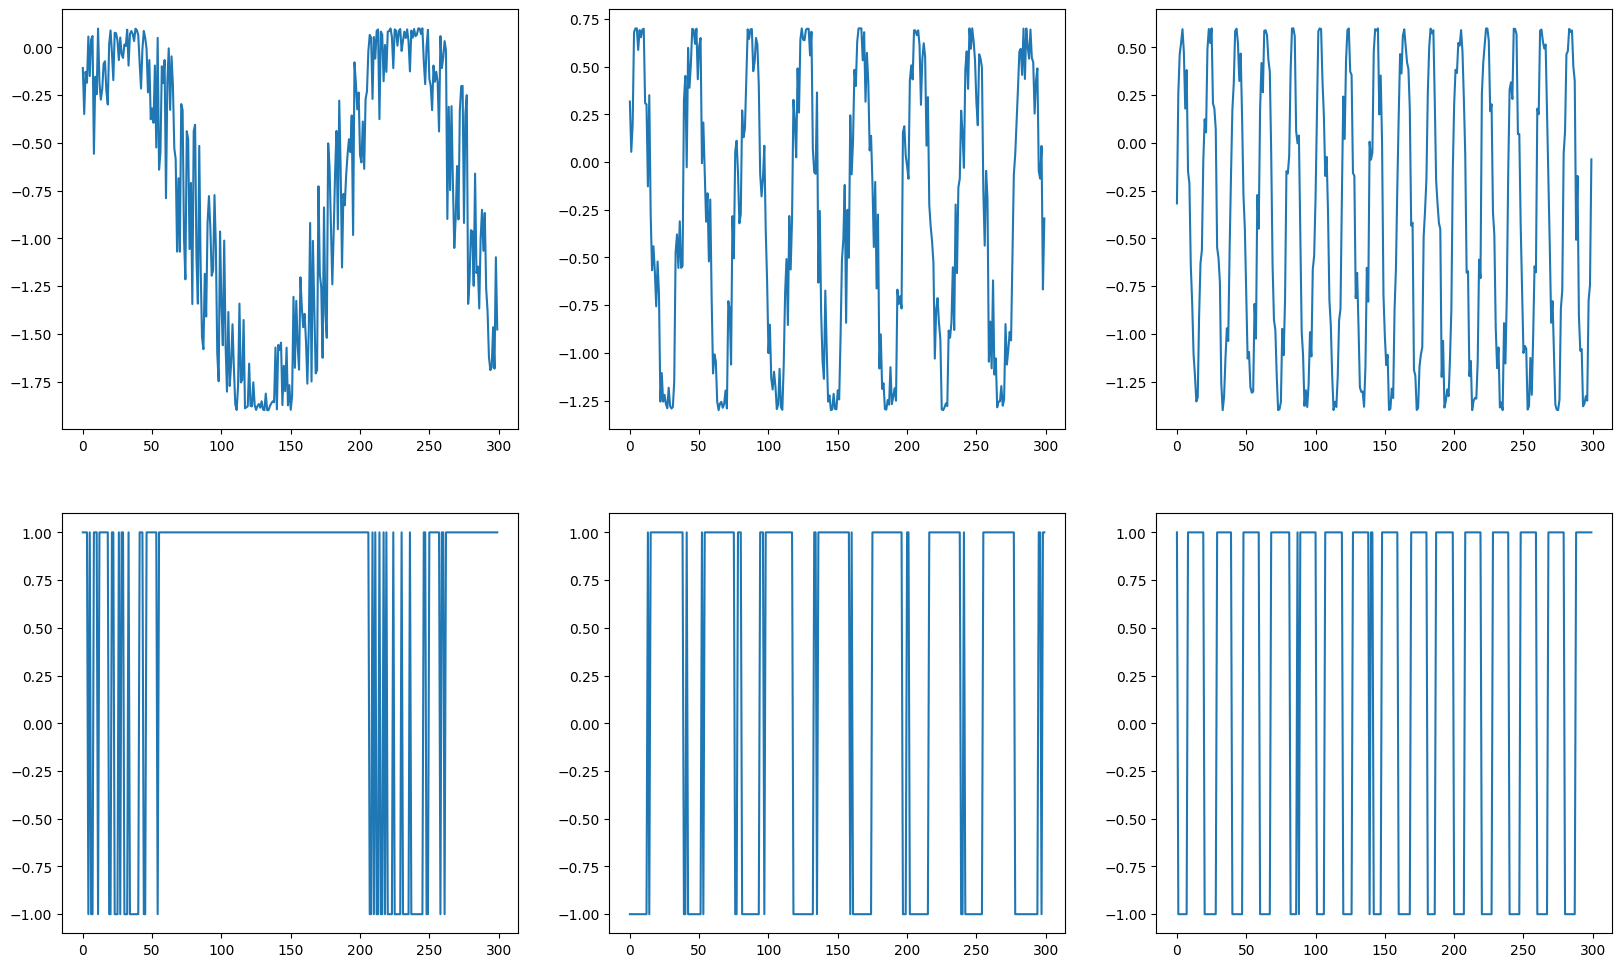

<Figure size 640x480 with 0 Axes>

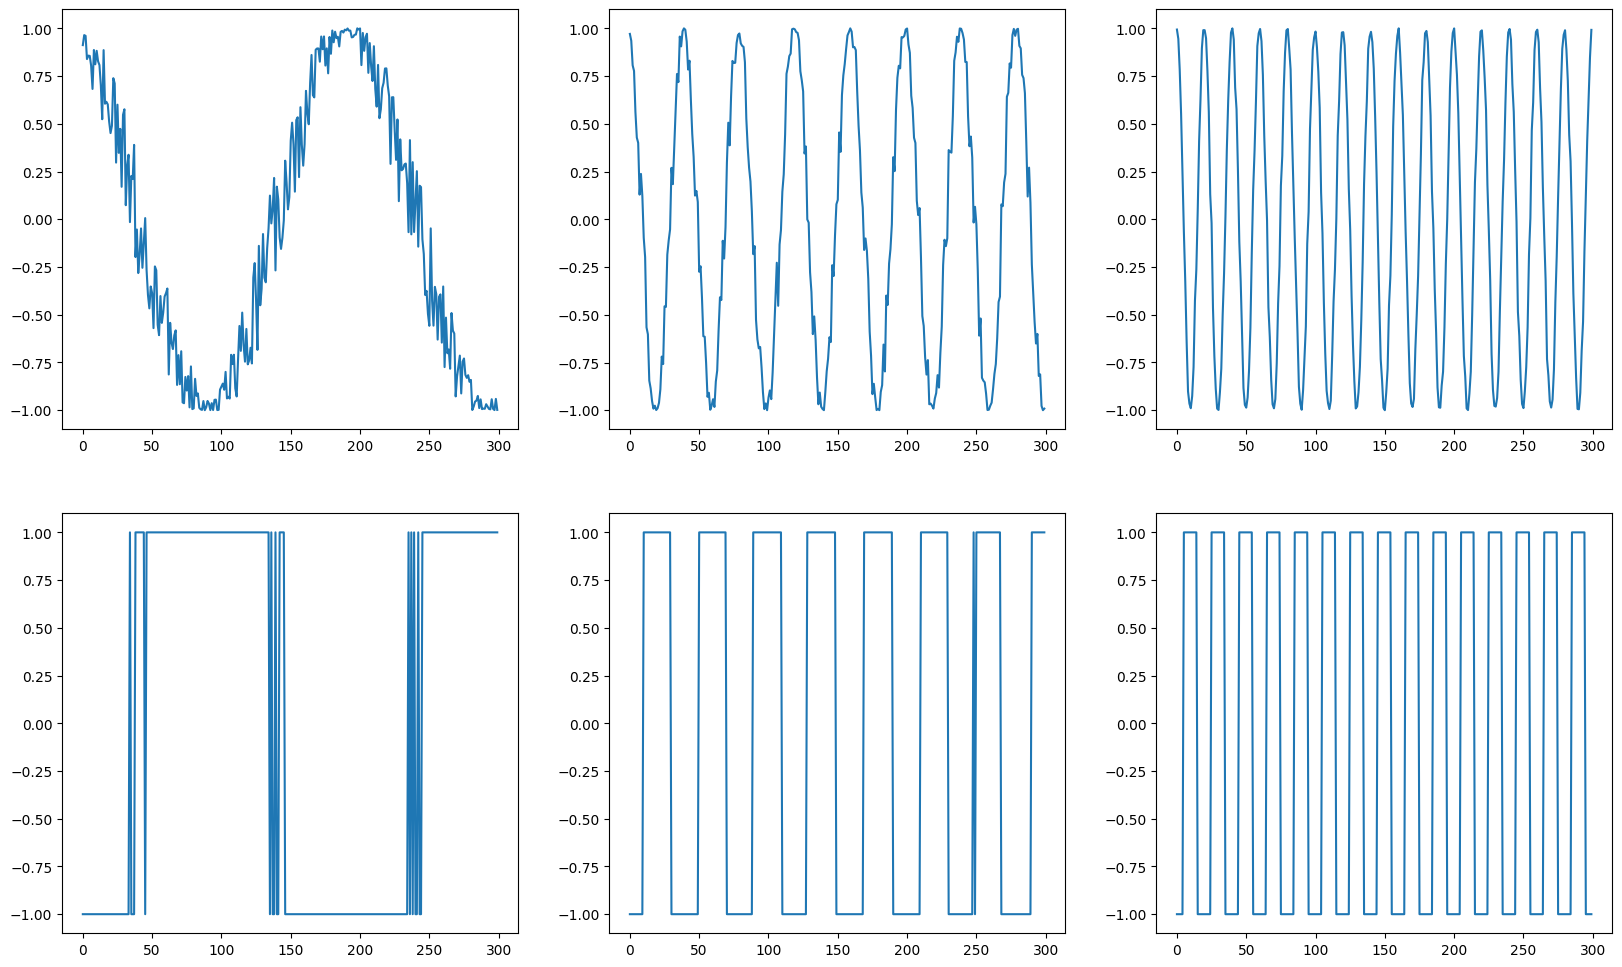

In [ ]:
from scipy.signal import chirp

N = 100000

rng1 = np.random.uniform(0, 1.2, N)
rng2 = np.random.uniform(0, 1, N)
rng3 = np.random.uniform(0, 0.8, N)
rng4 = np.random.uniform(0, 0.6, N)
rng5 = np.random.uniform(0, 0.4, N)
rng6 = np.random.uniform(0, 0.2, N)

X_sin1 = np.sin(np.arange(N) * 0.01 * np.pi + rng1) - 0.9
X_sin2 = np.sin(np.arange(N) * 0.05 * np.pi + rng2) - 0.3
X_sin3 = np.sin(np.arange(N) * 0.1 * np.pi + rng3) - 0.4
X_cos1 = np.cos(np.arange(N) * 0.01 * np.pi + rng4)
X_cos2 = np.cos(np.arange(N) * 0.05 * np.pi + rng5)
X_cos3 = np.cos(np.arange(N) * 0.1 * np.pi + rng6)

X_squre1 = -np.sign(X_sin1)
X_squre2 = -np.sign(X_sin2)
X_squre3 = -np.sign(X_sin3)
X_squre4 = -np.sign(X_cos1)
X_squre5 = -np.sign(X_cos2)
X_squre6 = -np.sign(X_cos3)

# Stack features
X1_EEG = np.column_stack((X_sin1, X_sin2, X_sin3))
X2_EEG = np.column_stack((X_squre1, X_squre2, X_squre3))

X1_EMG = np.column_stack((X_cos1, X_cos2, X_cos3))
X2_EMG = np.column_stack((X_squre4, X_squre5, X_squre6))

# Make epochs
X_EEG_class1_epoch = X1_EEG.reshape(100, 1000, 3)
X_EEG_class2_epoch = X2_EEG.reshape(100, 1000, 3)

X_EMG_class1_epoch = X1_EMG.reshape(100, 1000, 3)
X_EMG_class2_epoch = X2_EMG.reshape(100, 1000, 3)

plt.figure()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes[0, 0].plot(X1_EEG[:300, 0], label='Sinusoidal Signal - Feature 1')
axes[0, 1].plot(X1_EEG[:300, 1], label='Sinusoidal Signal - Feature 2')
axes[0, 2].plot(X1_EEG[:300, 2], label='Sinusoidal Signal - Feature 3')

axes[1, 0].plot(X2_EEG[:300, 0], label='Square Signal - Feature 1')
axes[1, 1].plot(X2_EEG[:300, 1], label='Square Signal - Feature 2')
axes[1, 2].plot(X2_EEG[:300, 2], label='Square Signal - Feature 3')

plt.figure()
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes[0, 0].plot(X1_EMG[:300, 0], label='Sinusoidal Signal - Feature 1')
axes[0, 1].plot(X1_EMG[:300, 1], label='Sinusoidal Signal - Feature 2')
axes[0, 2].plot(X1_EMG[:300, 2], label='Sinusoidal Signal - Feature 3')

axes[1, 0].plot(X2_EMG[:300, 0], label='Square Signal - Feature 1')
axes[1, 1].plot(X2_EMG[:300, 1], label='Square Signal - Feature 2')
axes[1, 2].plot(X2_EMG[:300, 2], label='Square Signal - Feature 3')

X, Y = None, None
EEG = np.concatenate((X_EEG_class1_epoch, X_EEG_class2_epoch))
EMG = np.concatenate((X_EMG_class1_epoch, X_EMG_class2_epoch))
labels = np.concatenate((np.zeros(X_EEG_class1_epoch.shape[0]), np.ones(X_EEG_class2_epoch.shape[0])))
# X = epoch_2t32['index']
# Y = np.zeros(epoch_2t32['index'].shape[0])

print(f'EEG shape: {EEG.shape}',
      f'\nEMG shape: {EMG.shape}',
      f'\nLabels shape: {labels.shape}')

In [88]:
X, Y = None, None
EEG_X = np.concatenate((eeg_epoch_con['index'], eeg_epoch_con['thumb']))
EMG_X = np.concatenate((emg_epoch_con['index'], emg_epoch_con['thumb']))
labels = np.concatenate((np.zeros(eeg_epoch_con['index'].shape[0]), np.ones(eeg_epoch_con['thumb'].shape[0])))
# X = epoch_2t32['index']
# Y = np.zeros(epoch_2t32['index'].shape[0])

print(f'EEG shape: {EEG_X.shape}',
      f'\nEMG shape: {EMG_X.shape}',
      f'\nLabels shape: {labels.shape}')

EEG shape: (210, 625, 16) 
EMG shape: (210, 200, 6) 
Labels shape: (210,)


In [101]:
class MultiModalDataset(torch.utils.data.Dataset):
    def __init__(self, eeg, emg, labels):
        self.eeg = torch.tensor(eeg, dtype=torch.float32)
        self.emg = torch.tensor(emg, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.rng = np.random.default_rng(SEED)
    
    def create_test_train_dataset(self, train_procent = 0.8):
        N_labels = len(labels)
        indices = self.rng.permutation(N_labels)            # Shuffle labels
        
        train_size = int(train_procent * N_labels)
        train_idx = indices[:train_size]
        test_idx  = indices[train_size:]

        return train_idx, test_idx
    
    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.eeg[idx], self.emg[idx], self.labels[idx]


## Step 4: Train the LSTM Model

In [ ]:
log_name = 'test_sherpa'
log_dir = os.path.abspath(os.path.join(os.getcwd(), f'loggings\{log_name}'))    # Path to log results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

dataset_ins = MultiModalDataset(EEG_X, EMG_X, labels)
train_eval_ins = FusionNet_train_eval()
train_idx, test_idx = dataset_ins.create_test_train_dataset(train_procent = 0.8)

num_epochs = 150
patience = 40                   # Early stopping patience - 25

L_all = {}
H_all = {}
Y_all = {}

for trial in study:
    lr = trial.parameters['learning_rate']
    dropout = trial.parameters['dropout']       
    batch_size = trial.parameters['batch_size']
    num_hidden_units = trial.parameters['num_hidden_units']
    activation = trial.parameters['activation'] 

    model = FusionNet(eeg_ch = 16, emg_ch = 6, hidden = num_hidden_units, lstm_layers = 1, num_classes = 2, dropout = dropout, activation = activation)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = lr)

    
    # Make a subset of data with desired indicies
    train_dataset = Subset(dataset_ins, train_idx)
    test_dataset  = Subset(dataset_ins, test_idx)

    # DataLoaders (update batch_size)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=pin_memory, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=pin_memory, num_workers=0)
    
    best_vloss = float('inf')
    running_vloss = 0.0
    early_stopping_counter = 0

    # Create log folder
    log_folder = os.path.join(log_dir, f"trial_{trial.id}")
    os.makedirs(log_folder, exist_ok=False)
    writer = SummaryWriter(os.path.join(log_folder, 'trial_{}_timestamp_{}'.format(trial.id, timestamp)))

    L_epo = []
    H_epo = []
    Y_epo = []

    for epoch in range(num_epochs):
        print('EPOCH {}:'.format(epoch + 1))

        # Make sure gradient tracking is on, and do a pass over the data
        model.train(True)

        # Train model
        avg_loss = train_eval_ins.train_one_epoch(model = model, train_loader = train_loader, criterion = criterion, optimizer = optimizer, device = device)

        # Set the model to evaluation mode
        model.eval()

        avg_vloss, vacc, inspect = train_eval_ins.evaluate_one_epoch(model = model, test_loader = test_loader, criterion = criterion, device = device)
        L, H, Y = inspect

        print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))

        # Collect all hidden states and labels for analysis
        L_epo.append(torch.cat(L).numpy())
        H_epo.append(torch.cat(H).numpy())
        Y_epo.append(torch.cat(Y).numpy())

        # Tensor Board logging
        writer.add_scalars('Loss', { 'Training' : avg_loss, 'Validation' : avg_vloss }, epoch + 1)
        writer.add_scalars('Accuracy Validation', {'Validation' : vacc }, epoch + 1)
        writer.flush()

        study.add_observation(trial = trial,
                              iteration = epoch,
                              objective = avg_vloss,
                              context={'avg_train_loss': avg_loss})

        
        # Track best performance, and save the model's state
        if avg_vloss < best_vloss:
            best_vloss = avg_vloss
            early_stopping_counter = 0
            print("New best model found at epoch {} with validation loss: {:.4f}".format(epoch + 1, avg_vloss))
            
            if avg_vloss < 0.6:
                torch.save(model.state_dict(), r'{}\model'.format(log_dir))
                print('model saved')

        else:
            early_stopping_counter += 1
            print("Early stopping counter: {}/{}".format(early_stopping_counter, patience))

            if early_stopping_counter >= patience:
                print("Early stopping triggered after {} epochs without improvement.".format(early_stopping_counter))
                break
        print('')
    
    L_all[trial.id] = L_epo
    H_all[trial.id] = H_epo
    Y_all[trial.id] = Y_epo

    writer.close()
    study.finalize(trial, status = 'COMPLETED')

EPOCH 1:
LOSS train 0.6938857038815817 valid 0.69752037525177


AttributeError: 'DataFrame' object has no attribute 'append'

## Step 5: Visulize class distribution from hidden states

In [72]:
npL = np.array(L_all)
npH = np.array(H_all)
npY = np.array(Y_all)
print(f'npL shape: {npL.shape}\n'
      f'npH shape: {npH.shape}\n' 
      f'npY shape: {npY.shape}')
# npH (epoch_idx, batches/trials, hidden_state)

npL shape: (100, 42, 2)
npH shape: (100, 42, 64)
npY shape: (100, 42)


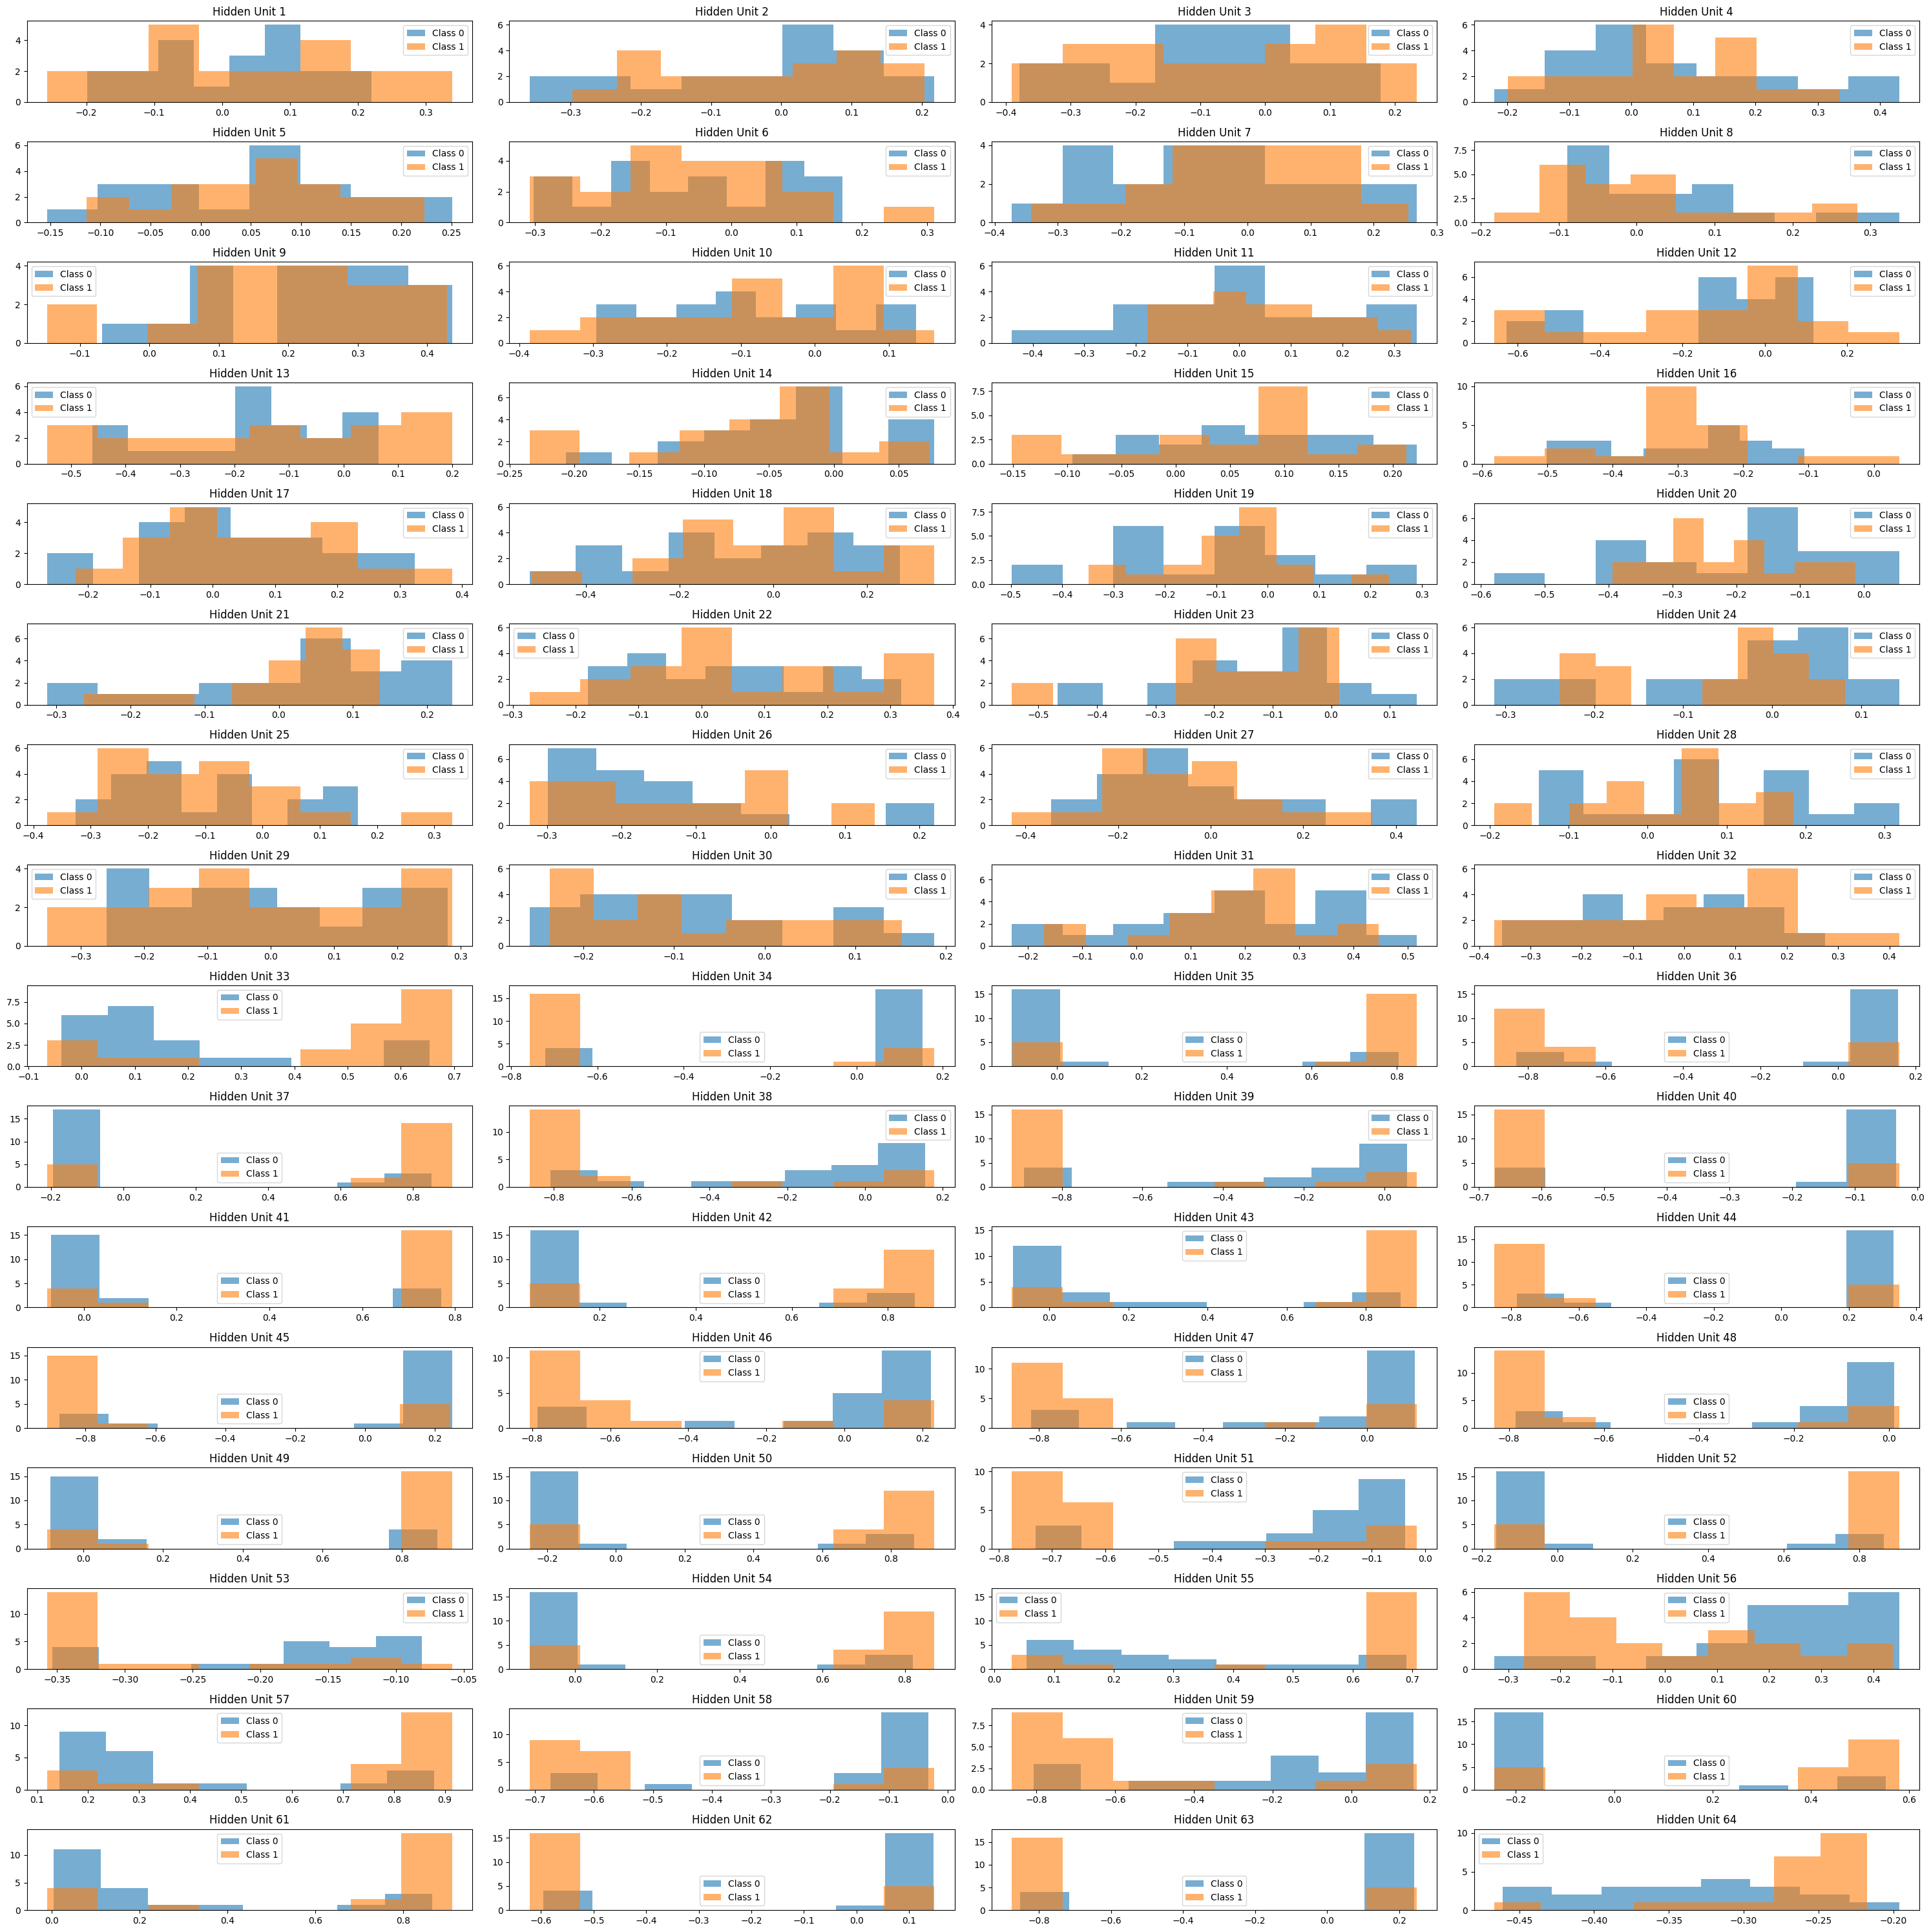

In [73]:
col_plots = 4
row_plots = int(np.ceil(npH.shape[2] / col_plots))
fig, ax = plt.subplots(row_plots, col_plots, figsize=(30, 30))

epo = 59  # Select which epoch to visualize
bins = int(np.ceil(np.sqrt(npH.shape[2])))      # Number of bins for histogram

x_max = np.max(npH)
x_min = np.min(npH)

for u in range(npH.shape[2]):
    # Boolean masks over batches
    mask0 = npY[epo, :] == 0
    mask1 = npY[epo, :] == 1

    # # Select hidden unit u for each class
    h0 = npH[epo, mask0, u]
    h1 = npH[epo, mask1, u]
    # print('h0 shape:', h0.shape, 'h1 shape:', h1.shape)
    # print("Class 0 std:", np.std(h0))
    # print("Class 1 std:", np.std(h1))

    r = u // col_plots
    c = u % col_plots
    ax[r, c].hist(h0, bins=bins, alpha=0.6, label="Class 0")
    ax[r, c].hist(h1, bins=bins, alpha=0.6, label="Class 1")
    ax[r, c].set_title(f'Hidden Unit {u+1}')
    ax[r, c].legend()
    #ax[r, c].set_xlim([0, ])

plt.tight_layout()
plt.show()

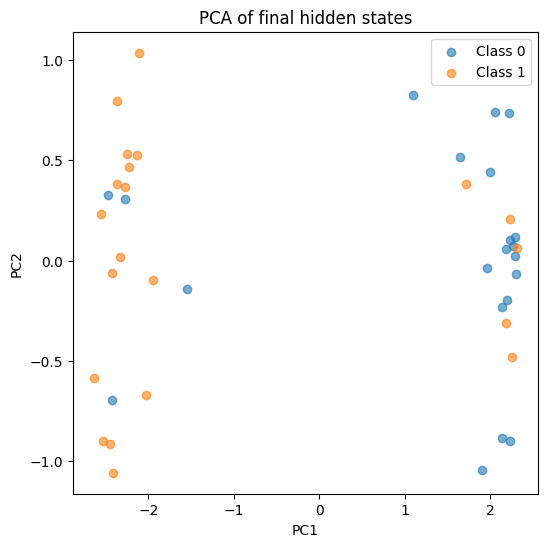

In [75]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
H_pca = pca.fit_transform(npH[epo, :, :])

plt.figure(figsize=(6,6))
# npY[epo, :] == 0 - Takes all hidden features where class is 0
# H_pca[npY[epo, :]==0, 0] - Takes all PC1 values where class is 0
plt.scatter(H_pca[npY[epo, :]==0, 0], H_pca[npY[epo, :]==0, 1], alpha=0.6, label="Class 0")
plt.scatter(H_pca[npY[epo, :]==1, 0], H_pca[npY[epo, :]==1, 1], alpha=0.6, label="Class 1")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of final hidden states")
plt.show()